R^2 Score: 0.6589


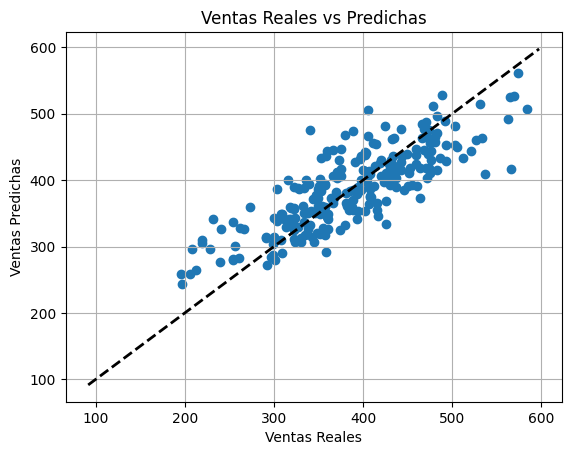

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder

# Cargar el dataset
data = pd.read_csv('ventas_ml_clase2.csv')
# Seleccionar las características y la variable objetivo (usar nombres reales en el CSV)
X = data.drop('ventas', axis=1) 
y = data['ventas']
# Dividir el dataset en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Crear un pipeline para el preprocesamiento y el modelo    
pipeline = Pipeline(steps=[
    ('preprocessor', ColumnTransformer(transformers=[
        ('num', 'passthrough', ['marketing', 'precio', 'temporada']),
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['tienda', 'canal'])
    ])),
    ('model', LinearRegression())
])  
# Entrenar el modelo
pipeline.fit(X_train, y_train)
# Evaluar el modelo
score = pipeline.score(X_test, y_test)
print(f'R^2 Score: {score:.4f}')
# Hacer predicciones
y_pred = pipeline.predict(X_test)
# Visualizar los resultados
plt.scatter(y_test, y_pred)
plt.xlabel('Ventas Reales')
plt.ylabel('Ventas Predichas')
plt.title('Ventas Reales vs Predichas')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.grid()
plt.show()

